In [1]:
#!sudo apt-get update
# Instala LaTeX (texlive) para que matplotlib pueda renderizar texto con usetex=True
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import matplotlib.pyplot as plt  # graficas

import matplotlib.colors as mcolors  # utilidades de color (no se usa directamente aqui)

import numpy as np  # arreglos y algebra lineal en CPU (sin autodiff)

# Configuracion global de estilo para todas las figuras del notebook
plt.rcParams.update({
    "text.usetex": True,            # usar LaTeX real para renderizar texto/formulas
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estetica
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

# --- JAX ---
import jax                         # libreria de autodiff + compilacion 
import jax.numpy as jnp            # tipo NumPy, pero con arreglos que JAX puede diferenciar
from jax import grad, jit, vmap    # grad: deriva funciones; jit: compila para acelerar; vmap: vectoriza sin loops explicitos

print('Configuracion OK')

Configuracion OK


In [2]:
# Carga de datos

data = np.load('../SolucionReferencia_0000/datos_0000.npz')
xdata = data['X']
ydata = data['y']
tdata = data['t']

#Extraemos una señal de cada régimen
x0 = xdata[3]
x1 = xdata[0]
x2 = xdata[4]

data.close()



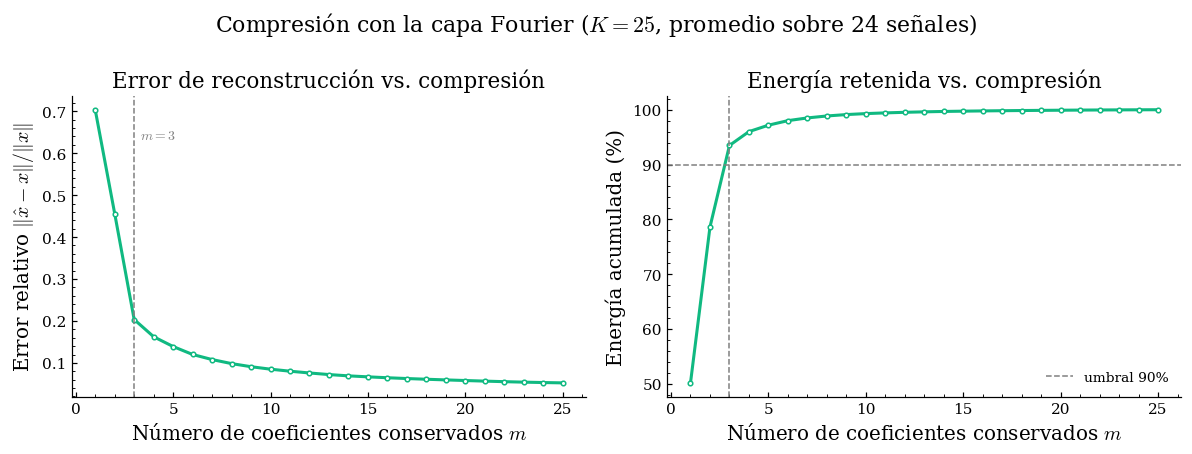

In [ ]:
m_axis = np.arange(1, K + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.plot(m_axis, error_medio, color=COL_G, lw=2, marker="o", ms=3, markerfacecolor="white")
ax1.axvline(m_umbral, color="gray", lw=1, ls="--")
ax1.text(m_umbral + 0.3, error_medio.max() * 0.9, f"$m={m_umbral}$", color="gray", fontsize=9)
ax1.set_xlabel("Número de coeficientes conservados $m$")
ax1.set_ylabel(r"Error relativo $\|\hat x - x\|/\|x\|$")
ax1.set_title("Error de reconstrucción vs. compresión")

ax2.plot(m_axis, energia_media_acum, color=COL_G, lw=2, marker="o", ms=3, markerfacecolor="white")
ax2.axhline(ENERGIA_UMBRAL, color="gray", lw=1, ls="--", label=f"umbral {ENERGIA_UMBRAL}%")
ax2.axvline(m_umbral, color="gray", lw=1, ls="--")
ax2.set_xlabel("Número de coeficientes conservados $m$")
ax2.set_ylabel("Energía acumulada (%)")
ax2.set_title("Energía retenida vs. compresión")
ax2.legend(frameon=False, fontsize=9)

fig.suptitle(f"Compresión con la capa Fourier ($K={K}$, promedio sobre {len(X)} señales)")
plt.tight_layout()
plt.show()


### Capa Fourier:

Sea $\eta:= \frac{2 \pi}{256}$. Sabemos que la matriz $\text{DFT}$ para secuencias de 256 elementos es

$$ 
\begin{align*}
    \text{DFT} &= \begin{bmatrix}
		e^{-i \cdot \eta \cdot 0 \cdot 0} & e^{-i \cdot\eta \cdot 0 \cdot 1} & \cdots & e^{-i \cdot\eta \cdot 0 \cdot 255} \\
			e^{-i \cdot\eta \cdot 1 \cdot 0} & e^{-i \cdot\eta \cdot 1 \cdot 1} & \cdots & e^{-i \cdot\eta \cdot 1 \cdot 255} \\
			\vdots & \vdots &  & \vdots \\
			e^{-i \cdot\eta \cdot 255 \cdot 0} & e^{-i \cdot\eta \cdot 255 \cdot 1} & \cdots & e^{-i \cdot\eta \cdot 255 \cdot 0}
		\end{bmatrix} \\& = 
        \begin{bmatrix}
        \cos(\eta \cdot 0 \cdot 0) & \cos(\eta \cdot 0 \cdot 1) & \cdots & \cos(\eta \cdot 0 \cdot 255) \\
        \cos(\eta \cdot 1 \cdot 0) & \cos(\eta \cdot 1 \cdot 1) & \cdots & \cos(\eta \cdot 1 \cdot 255) \\
        \vdots & \vdots & \ddots & \vdots \\
        \cos(\eta \cdot 255 \cdot 0) & \cos(\eta \cdot 255 \cdot 1) & \cdots & \cos(\eta \cdot 255 \cdot 255)
        \end{bmatrix} - i \begin{bmatrix}
        \sin(\eta \cdot 0 \cdot 0) & \sin(\eta \cdot 0 \cdot 1) & \cdots & \sin(\eta \cdot 0 \cdot 255) \\
        \sin(\eta \cdot 1 \cdot 0) & \sin(\eta \cdot 1 \cdot 1) & \cdots & \sin(\eta \cdot 1 \cdot 255) \\
        \vdots & \vdots & \ddots & \vdots \\
        \sin(\eta \cdot 255 \cdot 0) & \sin(\eta \cdot 255 \cdot 1) & \cdots & \sin(\eta \cdot 255 \cdot 255)
        \end{bmatrix}

    \end{align*}
$$

En ` makeFourierMatrix` construimos la siguiente matriz:

$$ M = \begin{bmatrix}
			\sin( \eta \cdot 1 \cdot 0) & \sin( \eta \cdot 1 \cdot 1) & \cdots & \sin( \eta \cdot 1 \cdot 255) \\
			\sin( \eta \cdot 2 \cdot 0) & \sin( \eta \cdot 2 \cdot 1) & \cdots & \sin( \eta \cdot 2 \cdot 255) \\
			\vdots & \vdots &  & \vdots  \\
			\sin( \eta \cdot 15 \cdot 0) & \sin( \eta \cdot 15 \cdot 1) & \cdots & \sin( \eta \cdot 15 \cdot 255) \\
            & & & & \\
			\cos( \eta \cdot 1 \cdot 0) & \cos( \eta \cdot 1 \cdot 0) & \cdots & \cos( \eta \cdot 1 \cdot 255)	
			\\
			\cos( \eta \cdot 2 \cdot 0) & \cos( \eta \cdot 2 \cdot 1) & \cdots & \cos( \eta \cdot 2 \cdot 255) \\
			\vdots &  &  &  \\
			\cos( \eta \cdot 15 \cdot 0) & \cos( \eta \cdot 15 \cdot 1) & \cdots & \cos( \eta \cdot 15 \cdot 255)
		\end{bmatrix} = \begin{bmatrix} - \text{Im}(\overline{\text{DFT}}) \\ \text{Re}(\overline{\text{DFT}}) \end{bmatrix}
$$
Donde $\overline{\text{DFT}}$ corresponde a las filas $i=1,...,15$ de $\text{DFT}$ esto es, estamos aislando las frecuencias correspondientes a estas filas, e ignorando todas las demás

Usando la función `parse` podemos convertir la salida de `jnp.fft.fft(xs)` (que corresponde a un array de numeros complejos) a este formato separando parte real e imaginaria, lo que nos permite comparar los resultados de la capa y de `fft`

In [3]:
def makeFourierMatrix(k_values: jnp.array,t_values: jnp.array):
    # Inicializar matrices vacias
    sins = jnp.zeros((len(k_values),len(t_values))) 
    cosins = jnp.zeros((len(k_values),len(t_values)))
    for t in range(len(t_values)):
        for k in range(len(k_values)):
            sins= sins.at[k,t].set(jnp.sin(2*jnp.pi*k_values[k]*t_values[t]))
            cosins= cosins.at[k,t].set(jnp.cos(2*jnp.pi*k_values[k]*t_values[t]))
    return jnp.vstack((sins,cosins)) #shape: len(k_values) x len(t_values)

def parse(x: jnp.array):
    # Para traducir la salida de jnp.fft.fft a la salida de la primera capa de la red
    x = jnp.asarray(x)
    im = x.imag
    re = x.real
    return jnp.concatenate((-im, re))

t_cont = jnp.arange(256) / 256
M = makeFourierMatrix(range(1,16),t_cont)


In [4]:
for x,title in zip([x0,x1,x2],['Régimen 1', 'Régimen 2','Régimen 3']): # Es esta la mejor forma de mostrar que coinciden?
    hMat = M @ x # Resultado construido con la capa de Fourier

    hFft = parse(jnp.fft.fft(x)[1:16]) #Resultado (parseado) de las frecuencias correspondientes de fft(xs)

    print(title, '-----------------')
    print("\t Resultado capa Fourier: \n", hMat)  
    print("\t Resultado FFT de jnp: \n", hFft)    
    if jnp.allclose(hMat, hFft, atol=1e-4):
        print('Coinciden')
    else:
        print('No coinciden')

Régimen 1 -----------------
	 Resultado capa Fourier: 
 [ 3.2327560e-01  1.6925749e-01  8.7130566e+00 -1.2026442e+02
  4.1105484e+01 -6.3308215e-01 -1.7741655e-01  1.9558859e-01
  8.1471190e-02  6.3048691e-01 -1.2142237e-01 -6.4942881e-02
  5.7639770e-02 -4.9604005e-01  4.3456554e-02  6.4006224e-02
 -1.5046503e-01 -1.1116076e+02 -3.1513877e+00 -8.3167175e+01
 -5.6204796e-03 -2.0541318e-01  2.8988922e-02 -3.4682059e-01
  7.7316843e-02 -5.5796838e-01 -9.4553009e-03  7.2385356e-02
  2.0620179e-01 -2.0091069e-01]
	 Resultado FFT de jnp: 
 [ 3.23274434e-01  1.69258609e-01  8.71305943e+00 -1.20264427e+02
  4.11054535e+01 -6.33079946e-01 -1.77418143e-01  1.95585459e-01
  8.14625397e-02  6.30486488e-01 -1.21427454e-01 -6.49420917e-02
  5.76276369e-02 -4.96047378e-01  4.34525609e-02  6.40051290e-02
 -1.50469273e-01 -1.11160751e+02 -3.15142226e+00 -8.31671906e+01
 -5.61633706e-03 -2.05427483e-01  2.90013030e-02 -3.46822768e-01
  7.73038790e-02 -5.57973385e-01 -9.45312530e-03  7.23995715e-02
  2.

In [5]:
print('Energia media del dataset: ')
print(f'\t  {(xdata**2).mean():.3}')

Energia media del dataset: 
	  0.678


## Generación y entrenamiento de la red

In [6]:

def genParams(key, fourierFlag):
    kw1, kw2 = jax.random.split(key,2)
    if not fourierFlag:
        params = {
            'W1': jax.random.uniform(kw1, (30,256)),
            'W2': jax.random.uniform(kw2, (256,30))
        }
    elif fourierFlag:
        params = {
            'W1': M, # Matriz ed Fourier construida mas arriba
            'W2': jax.random.uniform(kw2, (256,30))
        }
    return params

def red(params,x):
    # Capa de Fourier
    h = params['W1'] @ x
    h = jnp.tanh(h)
    # Capa final
    h = params['W2'] @ h
    return h # h = W2 * tanh(W1 * x)
    
def loss(params, x, y):
    # x: datos de entrada para la red
    # y: datos objetivo 
    y_hat = red(params,x)
    return jnp.mean((y-y_hat)**2)

gradLoss = jit(grad(loss))


In [7]:

key = jax.random.key(5628)
# Chistoso: con esta semilla en particular los resultados de la inicializacion aleatoria
# son _mucho_ mejores que lo usual y la ponen al mismo nivel/ mejor que usando una capa
# de Fourier al inicio

resultados = {
    'Reg0-Fourier': {
        'key': key, 
        'paramsIniciales': genParams(key,True),
        'x': x0,
        'paramsFinales': None,
        'perdidas': [],
        'out' : None,
        'benchmark' : 0
        },
    'Reg1-Fourier': {
        'key': key, 
        'paramsIniciales': genParams(key,True),
        'x': x1,
        'paramsFinales': None,
        'perdidas': [],
        'out' : None,
        'benchmark' : 0
        },
    'Reg2-Fourier': {
        'key': key, 
        'paramsIniciales': genParams(key,True),
        'x': x2,
        'paramsFinales': None,
        'perdidas': [],
        'out' : None,
        'benchmark' : 0
        },
    'Reg0-Random': {
        'key': key, 
        'paramsIniciales': genParams(key,False),
        'x': x0,
        'paramsFinales': None,
        'perdidas': [],
        'out' : None,
        'benchmark' : 0
        },
    'Reg1-Random': {
        'key': key, 
        'paramsIniciales': genParams(key,False),
        'x': x1,
        'paramsFinales': None,
        'perdidas': [],
        'out' : None,
        'benchmark' : 0
        },
    'Reg2-Random': {
        'key': key, 
        'paramsIniciales': genParams(key,False),
        'x': x2,
        'paramsFinales': None,
        'perdidas': [],
        'out' : None,
        'benchmark' : 0
        },
}

In [8]:
def train(params, x, perdidas, eta = 0.05, maxIter = 4000):
    for iter in range(maxIter):
        flag = True
        grads = gradLoss(params,x,x)
        params = jax.tree_util.tree_map(lambda par,grad : par - grad * eta, params, grads)
        perdidas.append(float(loss(params,x,x)))
        if loss(params,x,x)/(jnp.mean(x**2)) > 0.01 and flag: # El lado derecho calcula (||x-xHat||/||x||)^2
            benchmark = iter
    return params, benchmark

In [9]:
# Entrenamos todas las redes, y almacenamos los resultados

for case in resultados.values():
    case['perdidas'] = [] # Limpieza
    case['paramsFinales'], case['benchmark'] = train(case['paramsIniciales'],case['x'],case['perdidas'])
    case['out'] = red(case['paramsFinales'], case['x'])

## Reconstrucción de las señales

#### Régimen 0:

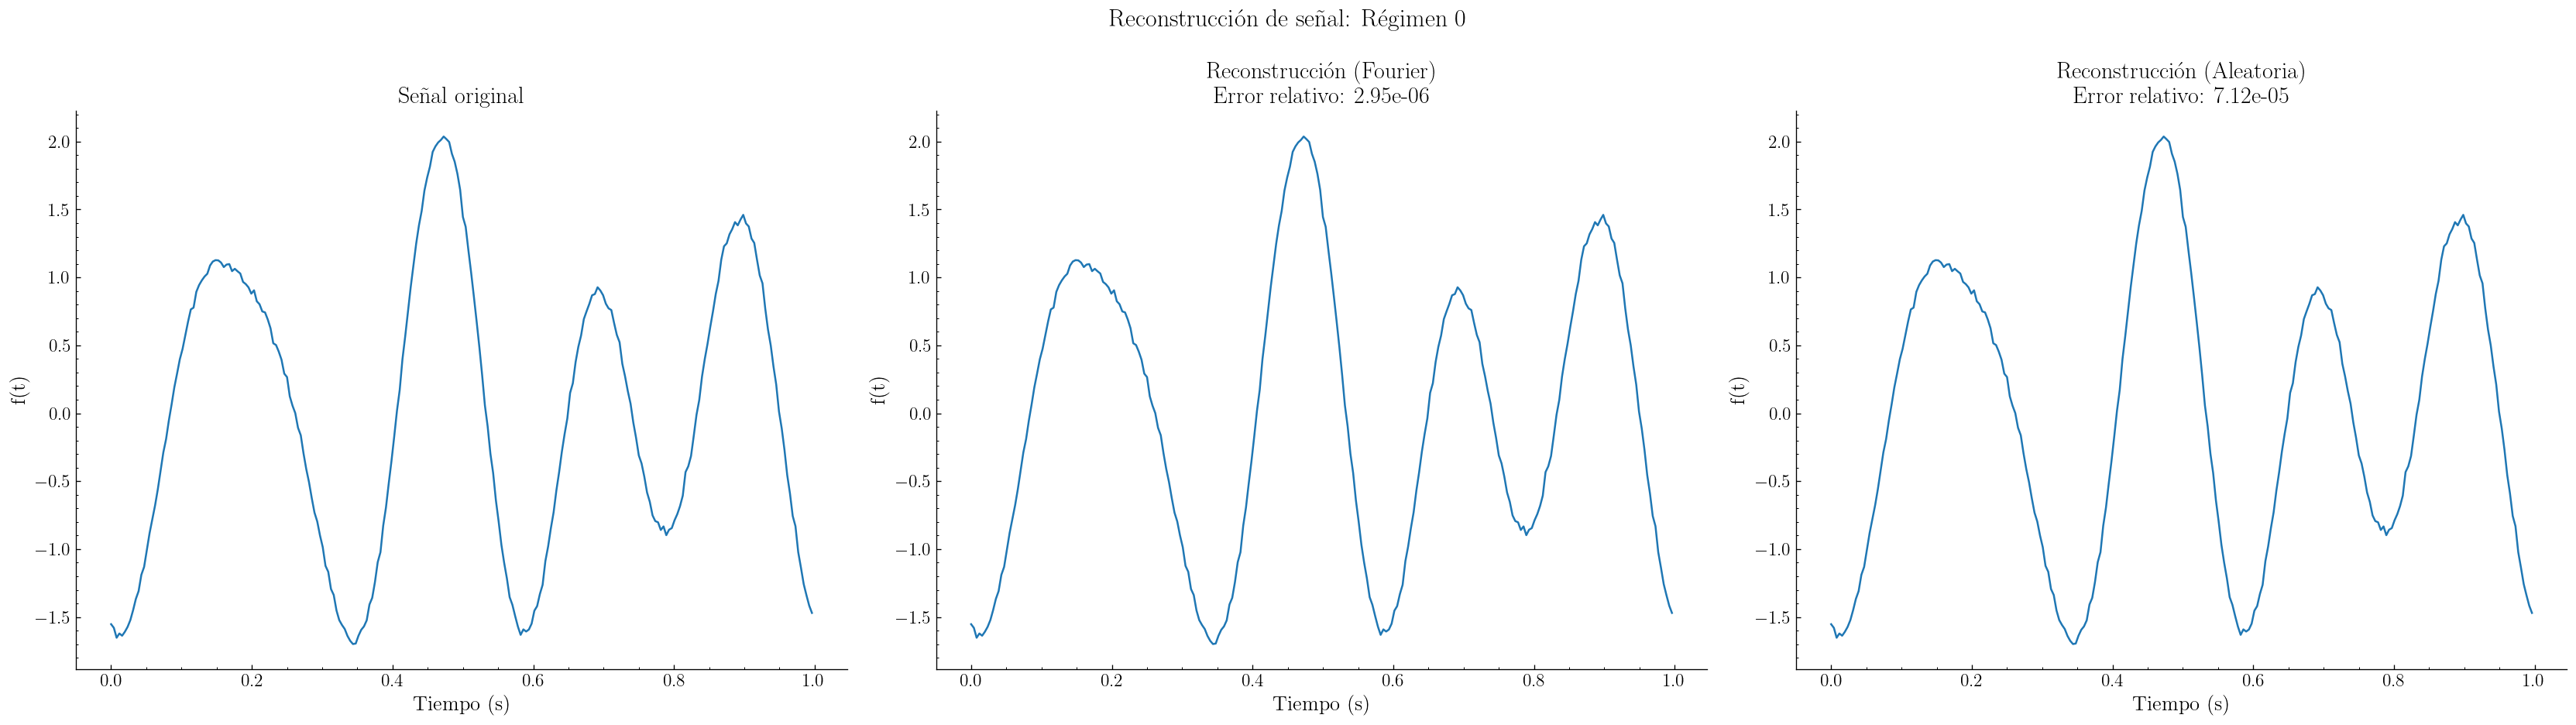

In [10]:
xReal = resultados['Reg0-Fourier']['x']
xFourier = resultados['Reg0-Fourier']['out']
xRandom = resultados['Reg0-Random']['out']

errorFourier = jnp.linalg.norm(xReal - xFourier)/jnp.linalg.norm(xReal)
errorRandom = jnp.linalg.norm(xReal - xRandom)/jnp.linalg.norm(xReal)

fig,axes = plt.subplots(1,3, figsize = (2*14,2*4))
ax0,ax1,ax2 = axes
ax0.plot(t_cont,xReal)
ax0.set_xlabel('Tiempo (s)'); ax0.set_ylabel('f(t)')
ax0.set_title('Señal original')
ax1.plot(t_cont,xFourier)
ax1.set_title(f'Reconstrucción (Fourier) \n Error relativo: {errorFourier:.2e}')
ax1.set_xlabel('Tiempo (s)'); ax1.set_ylabel('f(t)')
ax2.plot(t_cont,xRandom)
ax2.set_title(f'Reconstrucción (Aleatoria) \n Error relativo: {errorRandom:.2e}')
ax2.set_xlabel('Tiempo (s)'); ax2.set_ylabel('f(t)')

fig.suptitle('Reconstrucción de señal: Régimen 0')

plt.tight_layout()
plt.show()


#### Régimen 1:

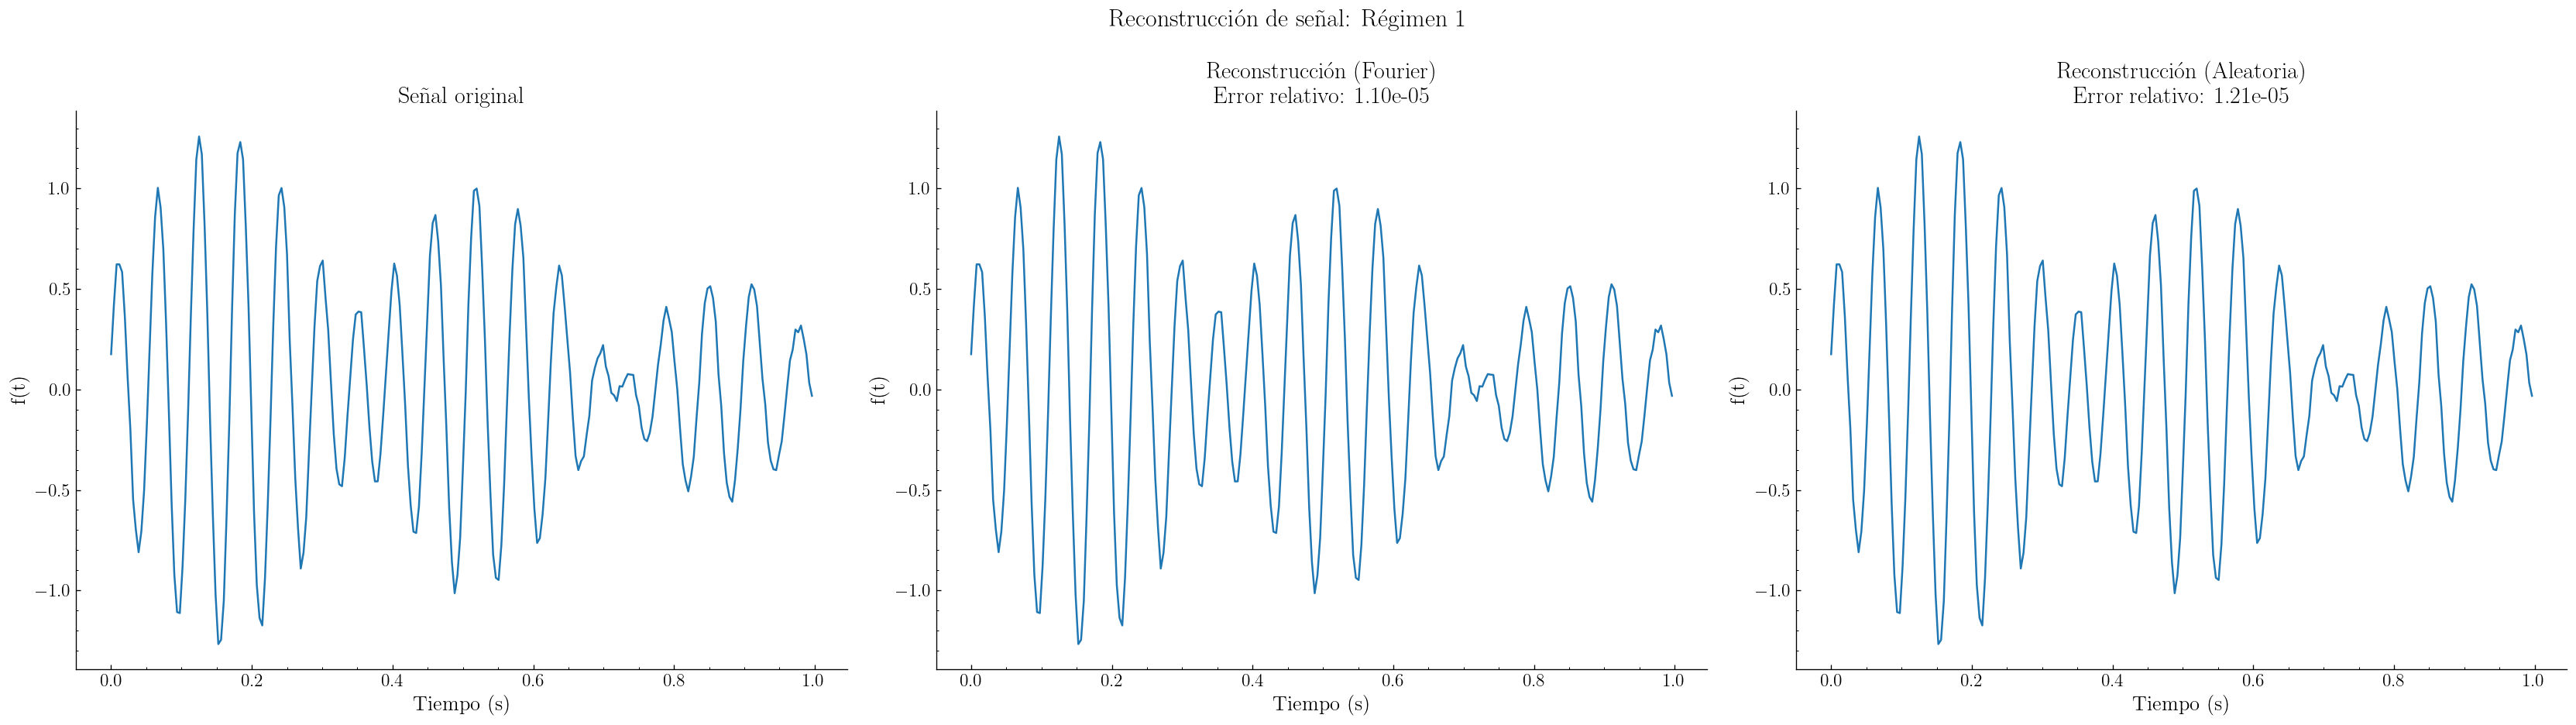

In [11]:
xReal = resultados['Reg1-Fourier']['x']
xFourier = resultados['Reg1-Fourier']['out']
xRandom = resultados['Reg1-Random']['out']

errorFourier = jnp.linalg.norm(xReal - xFourier)/jnp.linalg.norm(xReal)
errorRandom = jnp.linalg.norm(xReal - xRandom)/jnp.linalg.norm(xReal)

fig,axes = plt.subplots(1,3, figsize = (2*14,2*4))
ax0,ax1,ax2 = axes
ax0.plot(t_cont,xReal)
ax0.set_xlabel('Tiempo (s)'); ax0.set_ylabel('f(t)')
ax0.set_title('Señal original')
ax1.plot(t_cont,xFourier)
ax1.set_title(f'Reconstrucción (Fourier) \n Error relativo: {errorFourier:.2e}')
ax1.set_xlabel('Tiempo (s)'); ax1.set_ylabel('f(t)')
ax2.plot(t_cont,xRandom)
ax2.set_title(f'Reconstrucción (Aleatoria) \n Error relativo: {errorRandom:.2e}')
ax2.set_xlabel('Tiempo (s)'); ax2.set_ylabel('f(t)')

fig.suptitle('Reconstrucción de señal: Régimen 1')

plt.tight_layout()
plt.show()


#### Régimen 2:

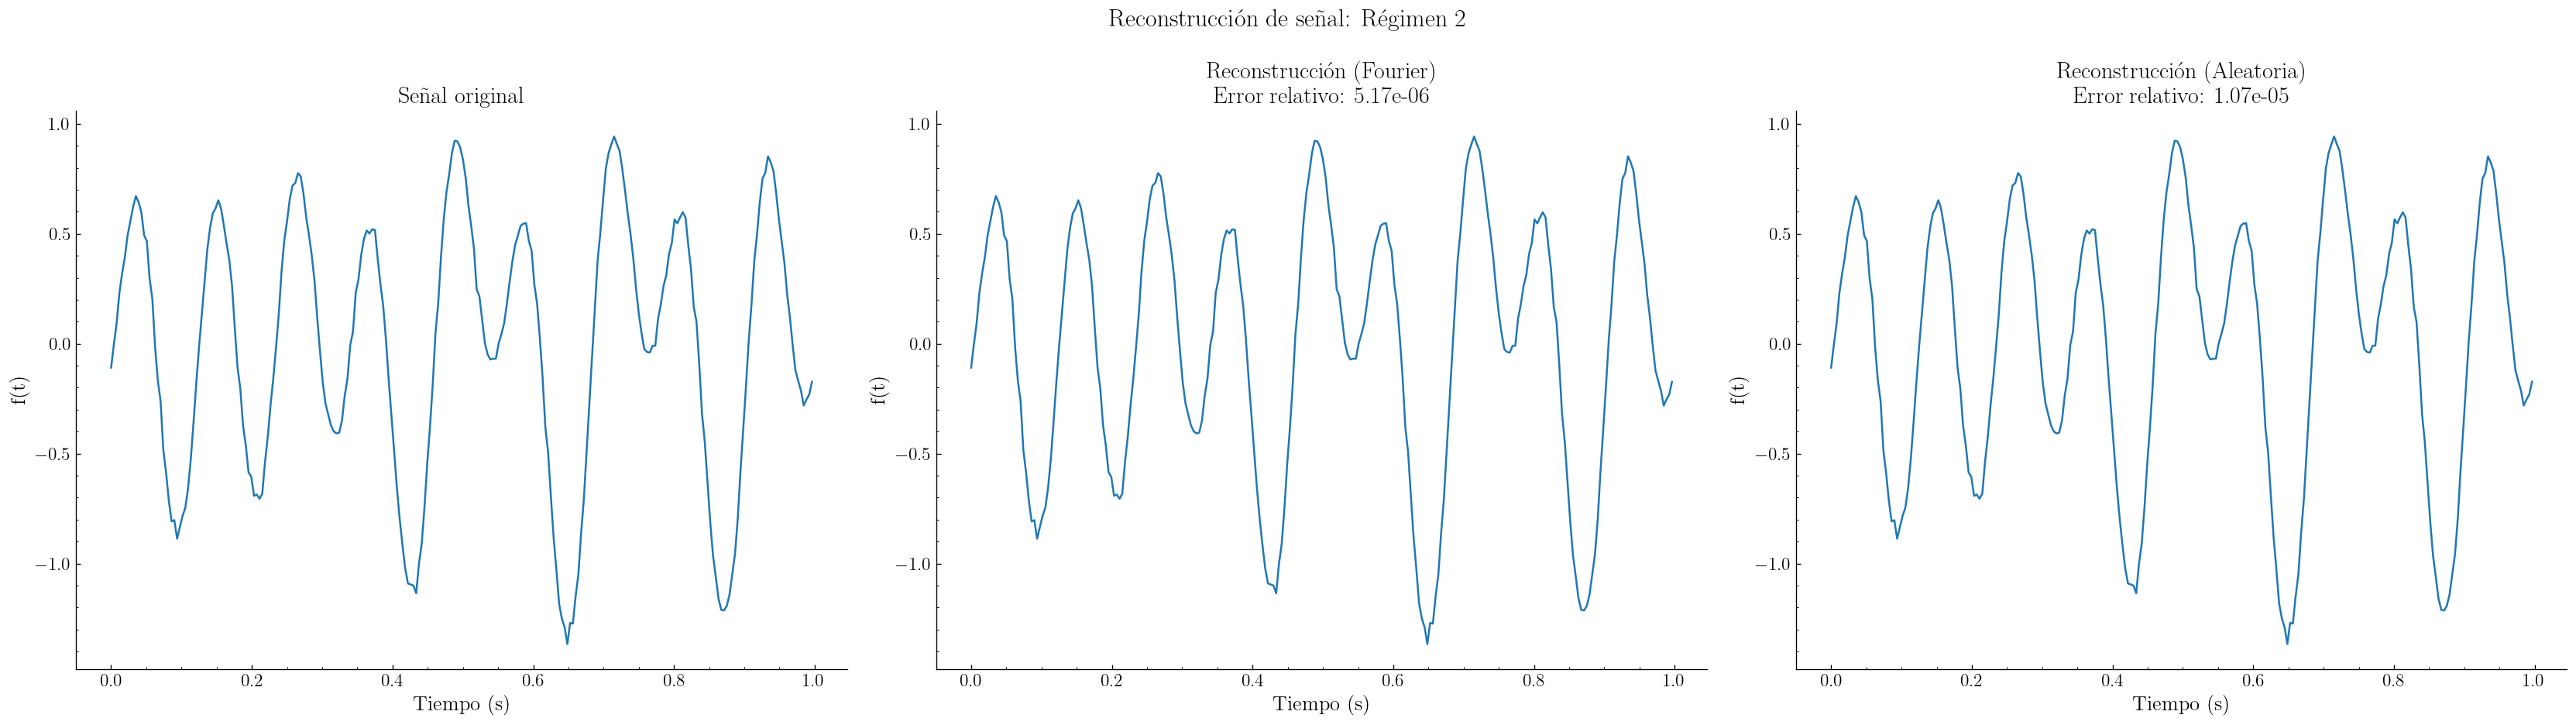

In [12]:
xReal = resultados['Reg2-Fourier']['x']
xFourier = resultados['Reg2-Fourier']['out']
xRandom = resultados['Reg2-Random']['out']

errorFourier = jnp.linalg.norm(xReal - xFourier)/jnp.linalg.norm(xReal)
errorRandom = jnp.linalg.norm(xReal - xRandom)/jnp.linalg.norm(xReal)

fig,axes = plt.subplots(1,3, figsize = (2*14,2*4))
ax0,ax1,ax2 = axes
ax0.plot(t_cont,xReal)
ax0.set_xlabel('Tiempo (s)'); ax0.set_ylabel('f(t)')
ax0.set_title('Señal original')
ax1.plot(t_cont,xFourier)
ax1.set_title(f'Reconstrucción (Fourier) \n Error relativo: {errorFourier:.2e}')
ax1.set_xlabel('Tiempo (s)'); ax1.set_ylabel('f(t)')
ax2.plot(t_cont,xRandom)
ax2.set_title(f'Reconstrucción (Aleatoria) \n Error relativo: {errorRandom:.2e}')
ax2.set_xlabel('Tiempo (s)'); ax2.set_ylabel('f(t)')

fig.suptitle('Reconstrucción de señal: Régimen 2')

plt.tight_layout()
plt.show()


## Comparación de inicializaciones: 

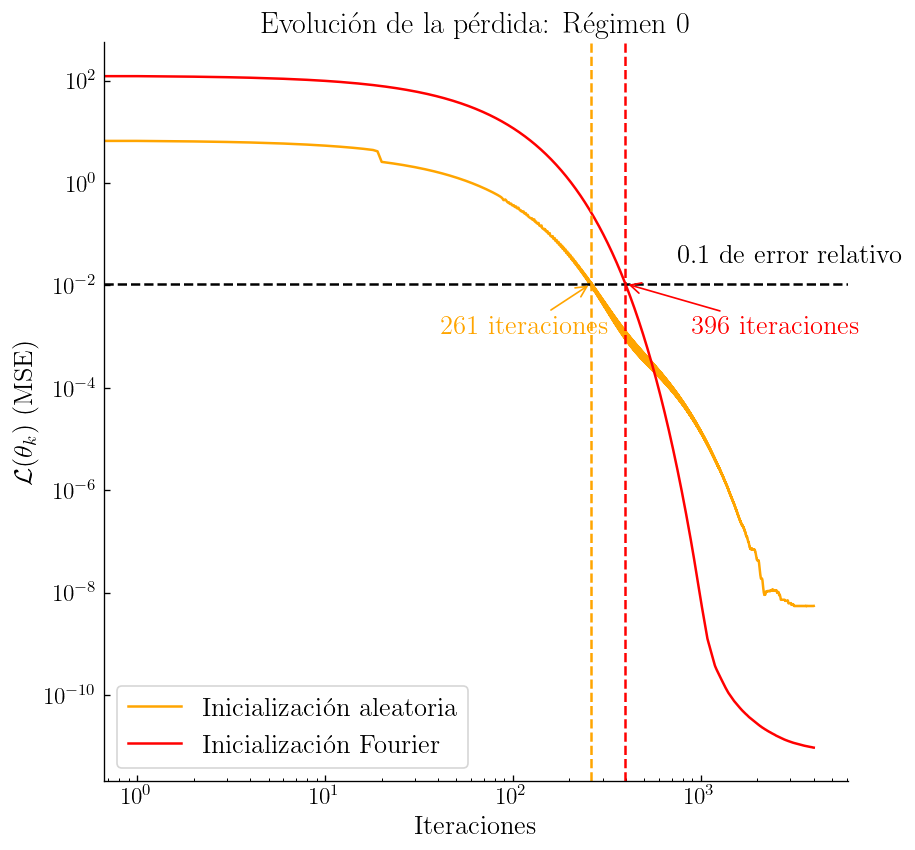

In [13]:

x = resultados['Reg0-Fourier']['x']
params = resultados['Reg0-Fourier']['paramsFinales']
perdidasFourier = resultados['Reg0-Fourier']['perdidas']
perdidasRandom = resultados['Reg0-Random']['perdidas']
xHat = red(params,x)

fig,ax = plt.subplots(1,1, figsize = (8,8))

ax.loglog(range(4000),perdidasRandom,color = 'orange', label='Inicialización aleatoria')
ax.loglog(range(4000),perdidasFourier,color = 'red', label = 'Inicialización Fourier')
ax.axhline(y=0.01*jnp.mean(x**2), color='black', linestyle='--')
ax.axvline(x=resultados['Reg0-Fourier']['benchmark'],color='red', linestyle = '--')
ax.axvline(x=resultados['Reg0-Random']['benchmark'],color='orange', linestyle = '--')
ax.annotate(
    text='0.1 de error relativo',             
    xy=(3000,0.01*jnp.mean(x**2)),                    
    xytext=(0, 10),               
    textcoords='offset points',    
    ha='center',                   
    va='bottom'                   
)
ax.annotate(
    f'{resultados['Reg0-Fourier']['benchmark']} iteraciones', 
    xy=(resultados['Reg0-Fourier']['benchmark'], 0.01*jnp.mean(x**2)), 
    xycoords='data',
    xytext=(40, -30), 
    textcoords='offset points',
    arrowprops=dict(arrowstyle="->", color="red"),
    color = 'red'
)

ax.annotate(
    f'{resultados['Reg0-Random']['benchmark']} iteraciones', 
    xy=(resultados['Reg0-Random']['benchmark'], 0.01*jnp.mean(x**2)), 
    xycoords='data',
    xytext=(-90, -30), 
    textcoords='offset points',
    arrowprops=dict(arrowstyle="->", color="orange"),
    color = 'orange'
)

ax.legend()
ax.set_xlabel('Iteraciones')
ax.set_ylabel(r'$\mathcal{L}(\theta_k)$ (MSE)')
ax.set_title('Evolución de la pérdida: Régimen 0')

plt.show()


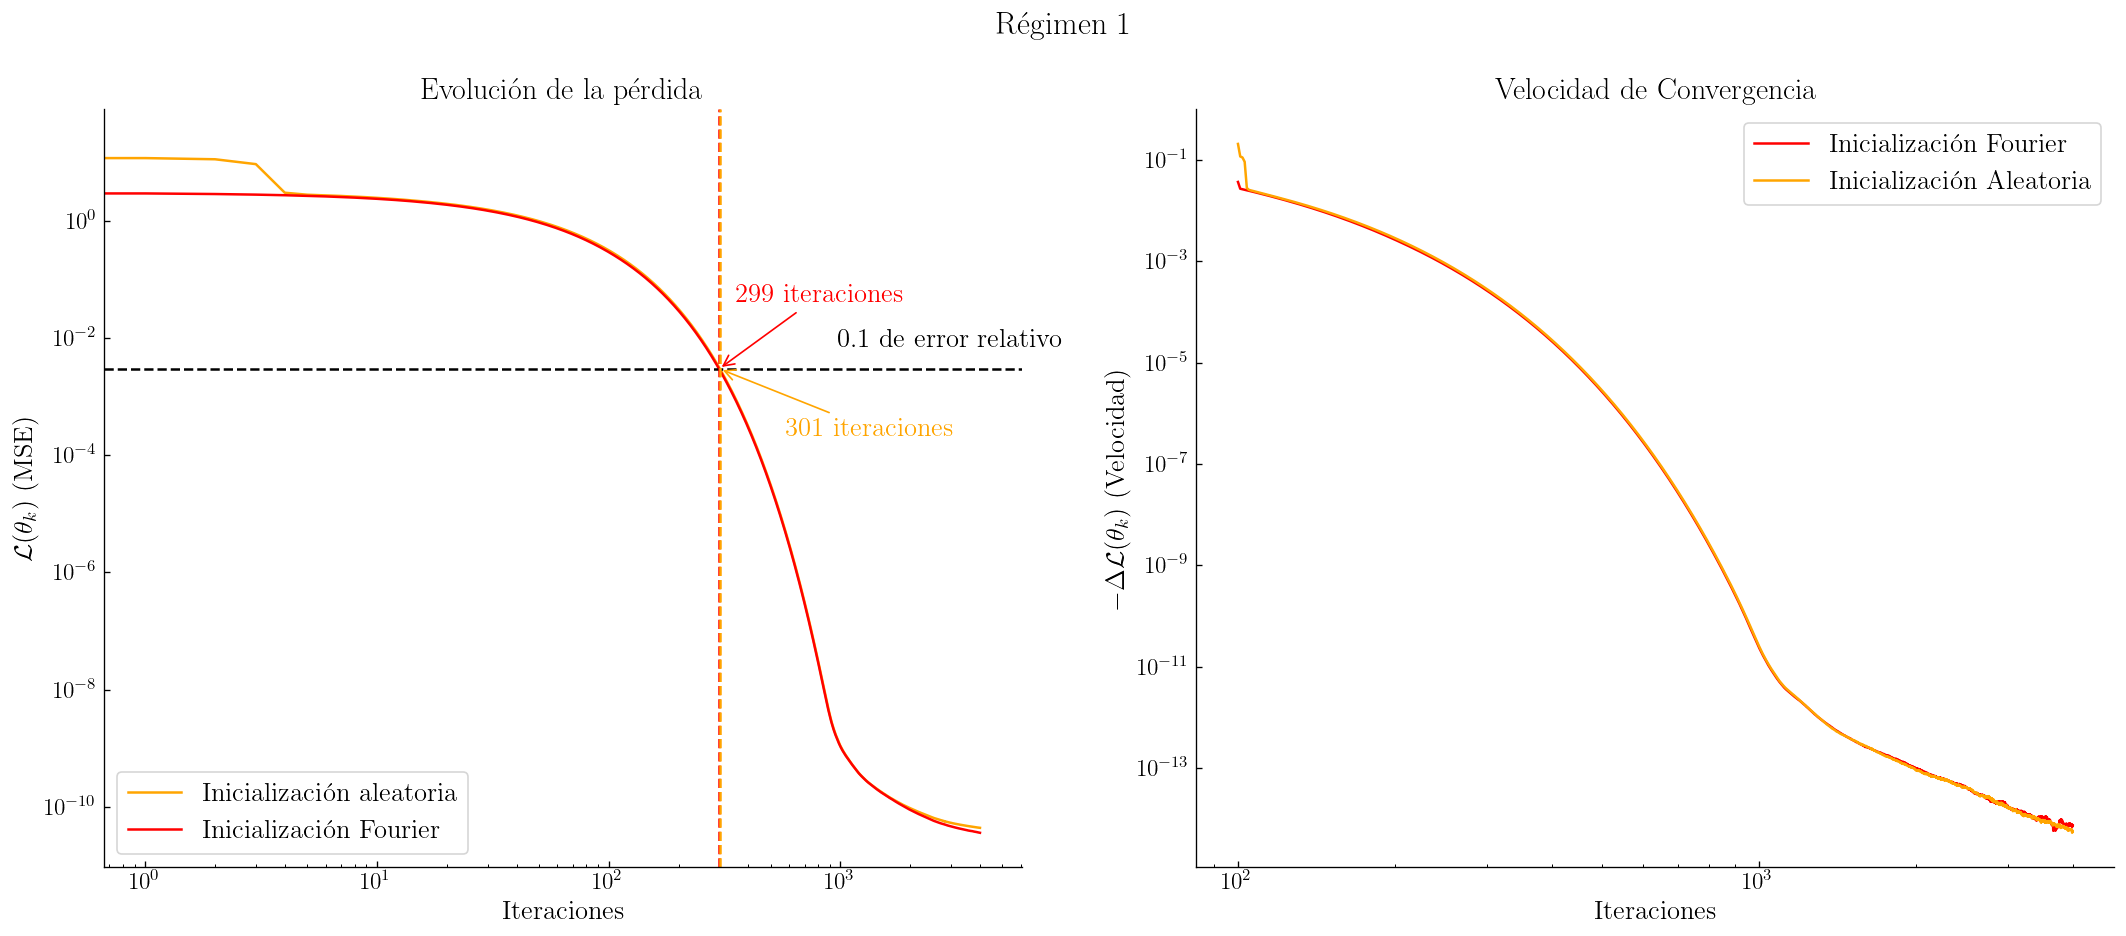

In [14]:
#print(resultados['Reg0-Fourier']['paramsFinales'])
x = resultados['Reg1-Fourier']['x']
params = resultados['Reg1-Fourier']['paramsFinales']
perdidasFourier = resultados['Reg1-Fourier']['perdidas']
perdidasRandom = resultados['Reg1-Random']['perdidas']

velocidadFourier = -jnp.diff(jnp.asarray(perdidasFourier))
velocidadRandom = -jnp.diff(jnp.asarray(perdidasRandom))

def moving_average(v, window_size):
    # Para limpiar la grafica de la derivada (numérica)
    return jnp.convolve(v, jnp.ones(window_size), mode='valid') / window_size

# Parametros de suavizado de la derivada
window_size = 100
vel_fourier_smooth = moving_average(velocidadFourier, window_size)
vel_random_smooth = moving_average(velocidadRandom, window_size)

total_epochs = len(perdidasFourier)
epochs_diff = range(1, total_epochs)                             
epochs_smooth = range(window_size, total_epochs)                 

xHat = red(params,x)


fig,axes = plt.subplots(1,2, figsize = (18,8))
ax,ax2 = axes
ax.loglog(range(4000),perdidasRandom,color = 'orange', label='Inicialización aleatoria')
ax.loglog(range(4000),perdidasFourier,color = 'red', label = 'Inicialización Fourier')
ax.axhline(y=0.01*jnp.mean(x**2), color='black', linestyle='--')
ax.axvline(x=resultados['Reg1-Fourier']['benchmark'],color='red', linestyle = '--')
ax.axvline(x=resultados['Reg1-Random']['benchmark'],color='orange', linestyle = '--')
ax.annotate(
    text='0.1 de error relativo',             
    xy=(3000,0.01*jnp.mean(x**2)),                    
    xytext=(0, 10),               
    textcoords='offset points',    
    ha='center',                   
    va='bottom'                   
)
ax.annotate(
    f'{resultados['Reg1-Fourier']['benchmark']} iteraciones', 
    xy=(resultados['Reg1-Fourier']['benchmark'], 0.01*jnp.mean(x**2)), 
    xycoords='data',
    xytext=(10, 40), 
    textcoords='offset points',
    arrowprops=dict(arrowstyle="->", color="red"),
    color = 'red'
)

ax.annotate(
    f'{resultados['Reg1-Random']['benchmark']} iteraciones', 
    xy=(resultados['Reg1-Random']['benchmark'], 0.01*jnp.mean(x**2)), 
    xycoords='data',
    xytext=(40, -40), 
    textcoords='offset points',
    arrowprops=dict(arrowstyle="->", color="orange"),
    color = 'orange'
)

ax.legend()
ax.set_xlabel('Iteraciones')
ax.set_ylabel(r'$\mathcal{L}(\theta_k)$ (MSE)')
ax.set_title('Evolución de la pérdida')

ax2.loglog(epochs_smooth, vel_fourier_smooth, color = 'red')
ax2.loglog(epochs_smooth, vel_random_smooth, color = 'orange')

ax2.set_xlabel('Iteraciones')
ax2.set_ylabel(r'$-\Delta \mathcal{L}(\theta_k)$ (Velocidad)')
ax2.set_title('Velocidad de Convergencia')
ax2.legend(['Inicialización Fourier', 'Inicialización Aleatoria'])

fig.suptitle('Régimen 1')

plt.tight_layout()
plt.show()



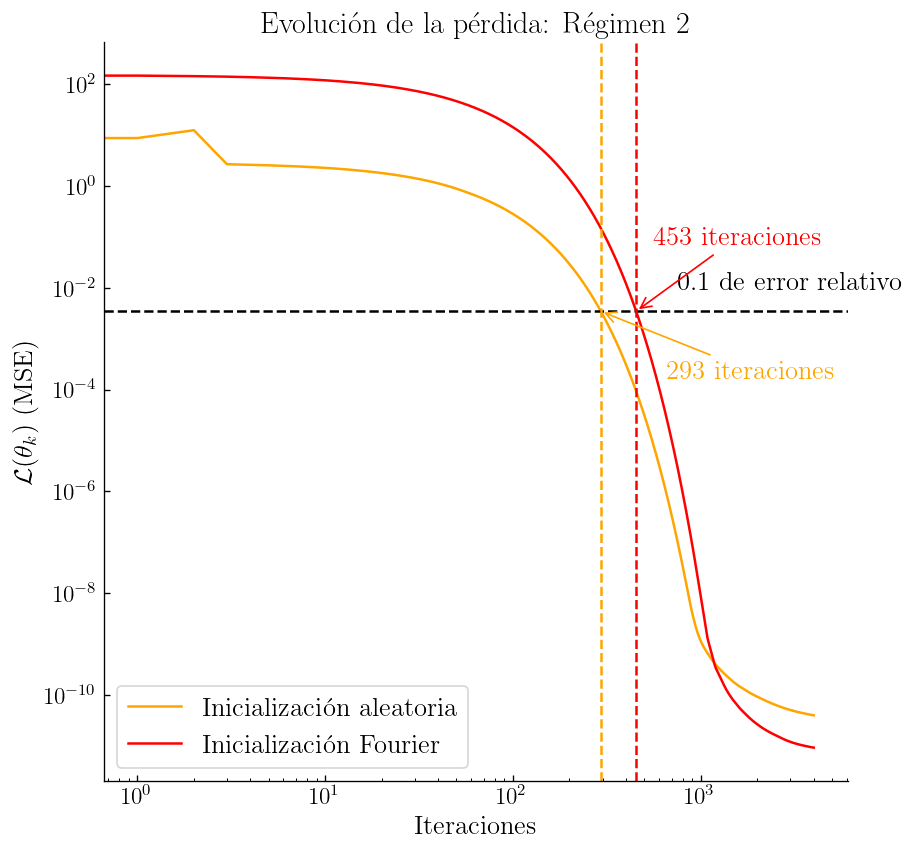

In [15]:

x = resultados['Reg2-Fourier']['x']
params = resultados['Reg2-Fourier']['paramsFinales']
perdidasFourier = resultados['Reg2-Fourier']['perdidas']
perdidasRandom = resultados['Reg2-Random']['perdidas']

xHat = red(params,x)



fig,ax = plt.subplots(1,1, figsize = (8,8))

ax.loglog(range(4000),perdidasRandom,color = 'orange', label='Inicialización aleatoria')
ax.loglog(range(4000),perdidasFourier,color = 'red', label = 'Inicialización Fourier')
ax.axhline(y=0.01*jnp.mean(x**2), color='black', linestyle='--')
ax.axvline(x=resultados['Reg2-Fourier']['benchmark'],color='red', linestyle = '--')
ax.axvline(x=resultados['Reg2-Random']['benchmark'],color='orange', linestyle = '--')
ax.annotate(
    text='0.1 de error relativo',             
    xy=(3000,0.01*jnp.mean(x**2)),                   
    xytext=(0, 10),                
    textcoords='offset points',    
    ha='center',                  
    va='bottom'                    
)
ax.annotate(
    f'{resultados['Reg2-Fourier']['benchmark']} iteraciones', 
    xy=(resultados['Reg2-Fourier']['benchmark'], 0.01*jnp.mean(x**2)), 
    xycoords='data',
    xytext=(10, 40), 
    textcoords='offset points',
    arrowprops=dict(arrowstyle="->", color="red"),
    color = 'red'
)

ax.annotate(
    f'{resultados['Reg2-Random']['benchmark']} iteraciones', 
    xy=(resultados['Reg2-Random']['benchmark'], 0.01*jnp.mean(x**2)), 
    xycoords='data',
    xytext=(40, -40), 
    textcoords='offset points',
    arrowprops=dict(arrowstyle="->", color="orange"),
    color = 'orange'
)

ax.legend()
ax.set_xlabel('Iteraciones')
ax.set_ylabel(r'$\mathcal{L}(\theta_k)$ (MSE)')
ax.set_title('Evolución de la pérdida: Régimen 2')

plt.show()

